In [ ]:
import aerosandbox as asb
from cessna152 import airplane

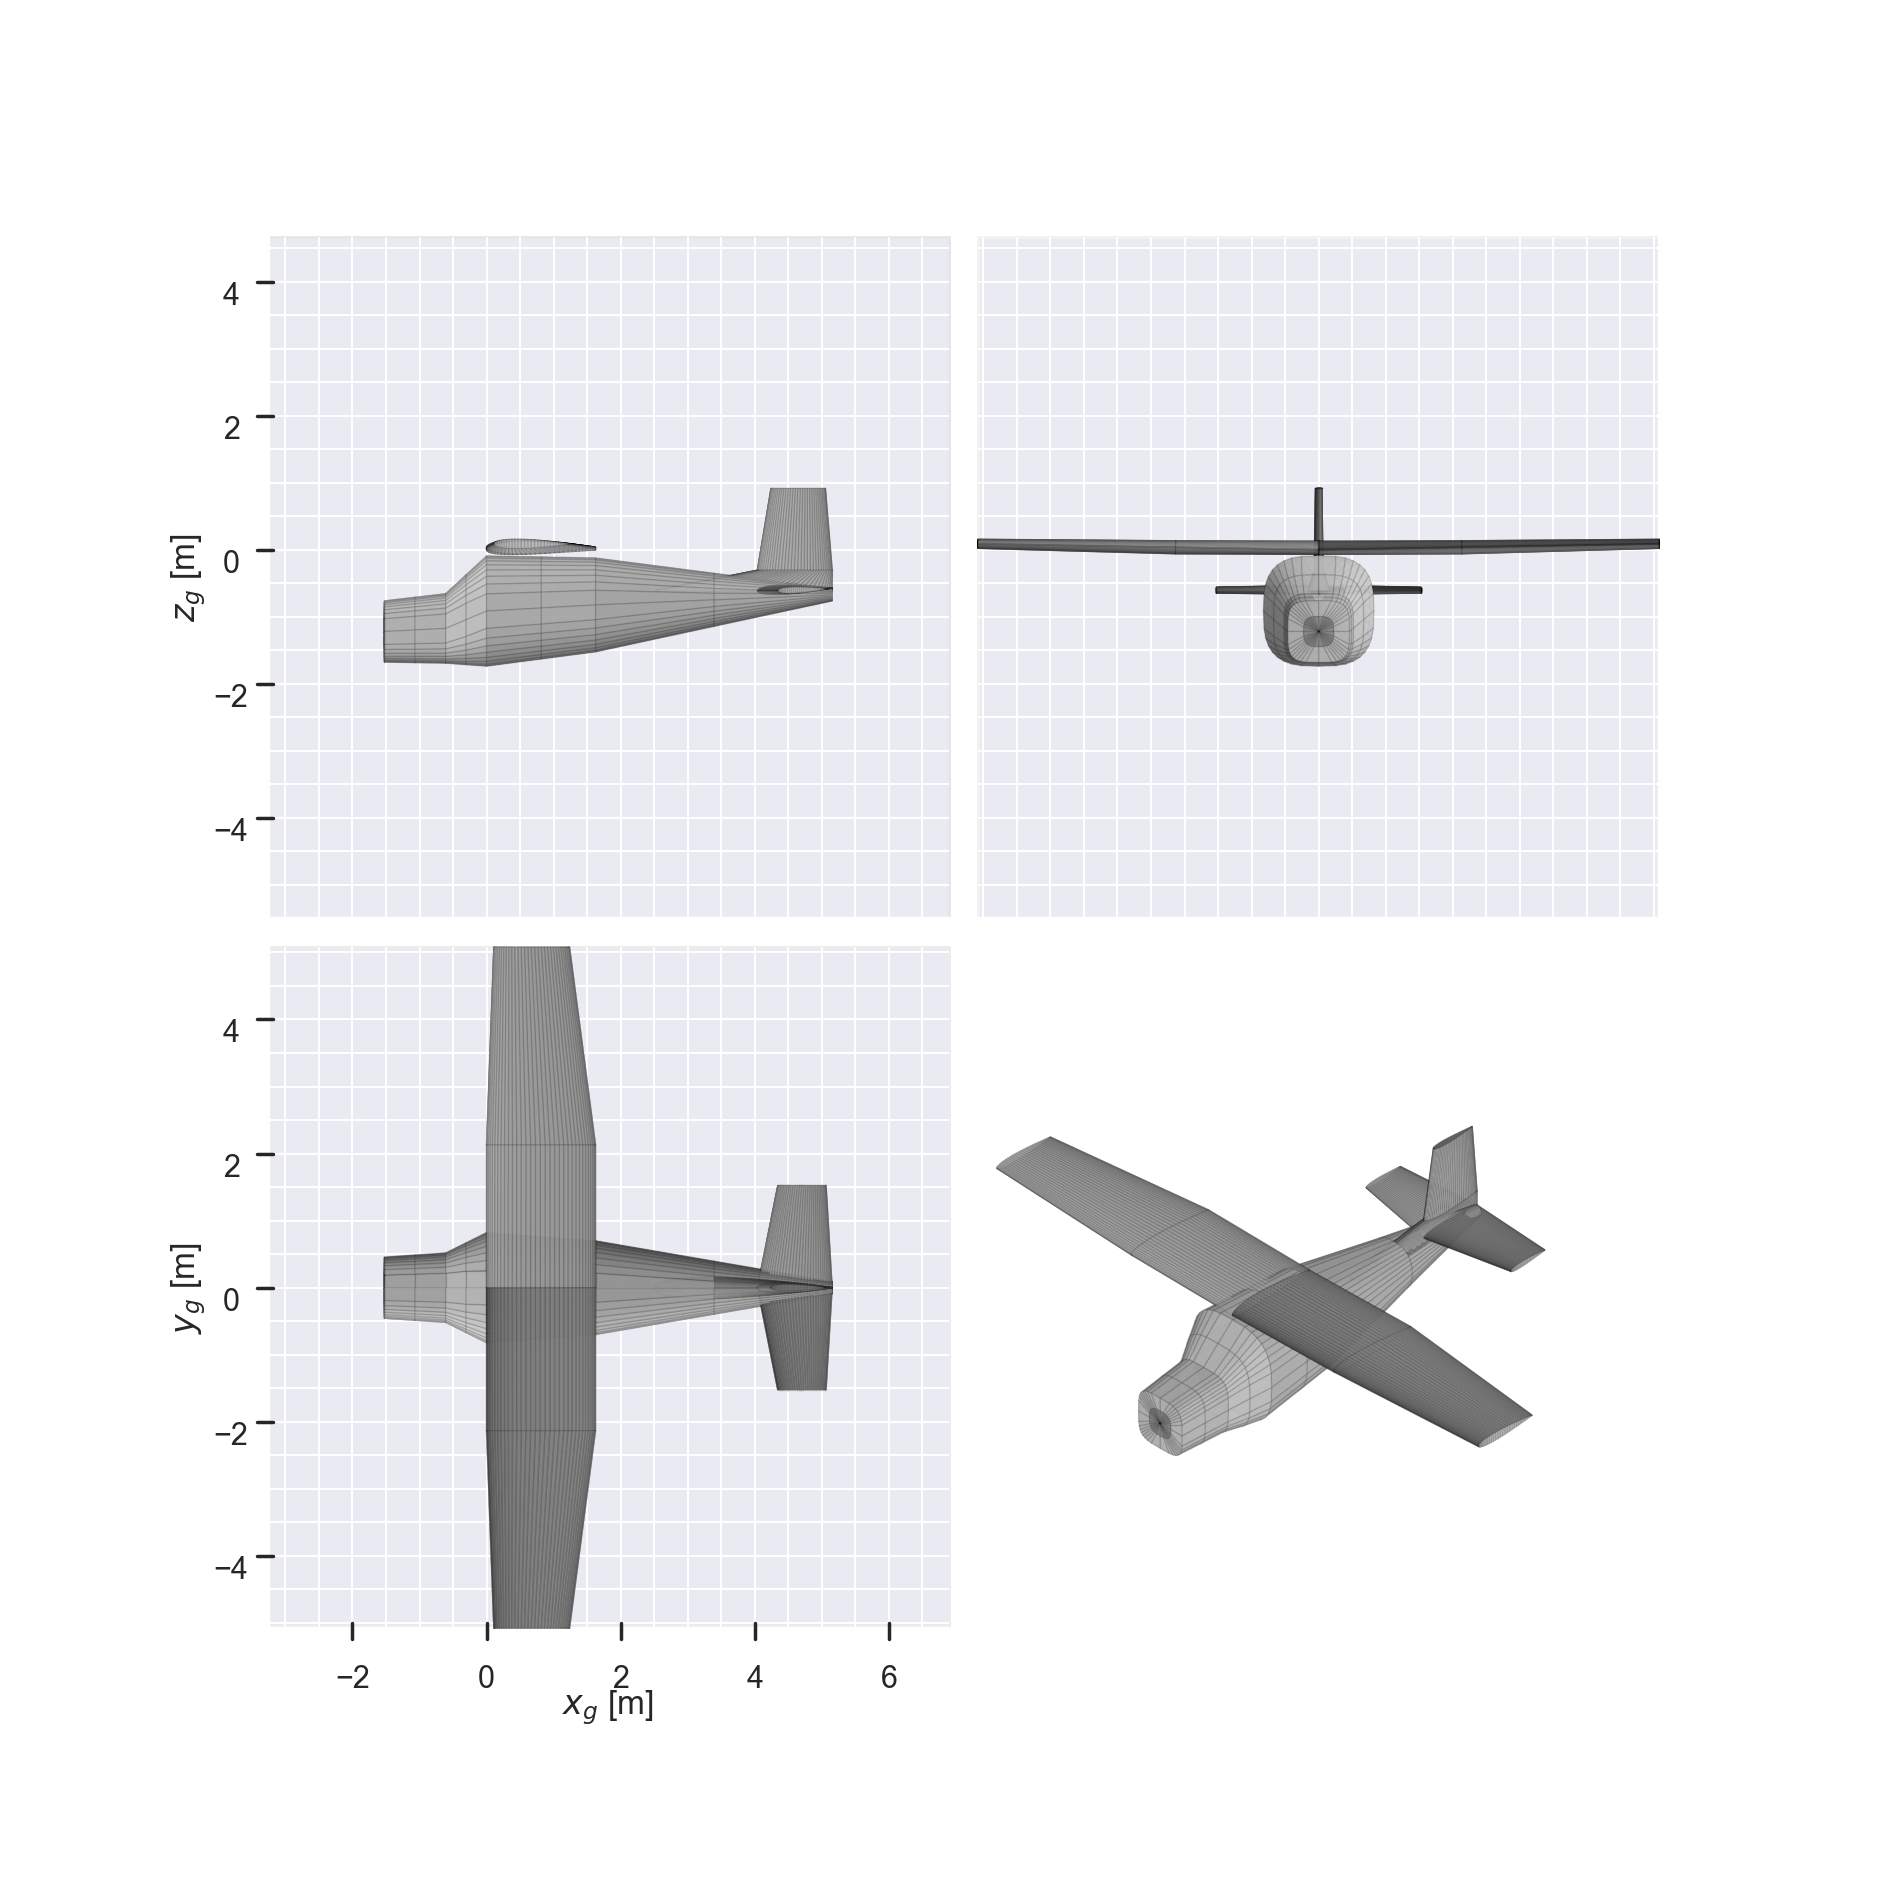

array([[<Axes3D: zlabel='$z_g$ [m]'>, <Axes3D: >],
       [<Axes3D: xlabel='$x_g$ [m]', ylabel='$y_g$ [m]'>, <Axes3D: >]],
      dtype=object)

In [ ]:
airplane.draw_three_view()

In [ ]:
op_point = asb.OperatingPoint(
    velocity=50.0,  # m/s
    alpha=5.0,  # degrees
)

# Aero Buildup

In [ ]:
aero['wing_aero_components'][0].F_w

(array([-139.46272288]), array([0.]), array([-11055.26006699]))

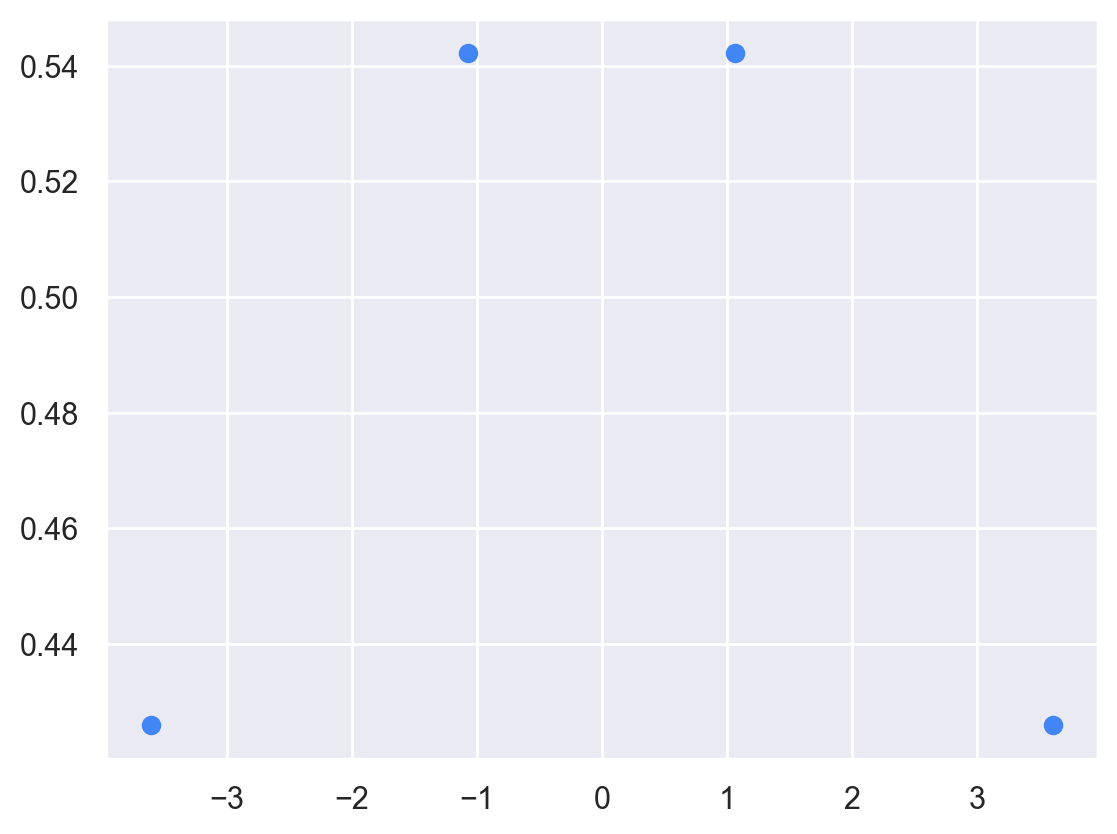

In [ ]:
CL_j = np.array(aero['wing_aero_components'][0].section_CL)


plt.scatter(y, CL_j, label='CL_local')

In [ ]:
aero_LLT = asb.LiftingLine(airplane=airplane, op_point=op_point, spanwise_spacing_function=np.cosspace,spanwise_resolution=8).run()

In [9]:
aero_LLT['wing_aero_components'].keys()

dict_keys(['Wing', 'Horizontal Stabilizer', 'Vertical Stabilizer'])

In [10]:
aero_LLT['wing_aero_components']['Wing'].panel_forces_w

array([[  -5.28456475,   -2.08256292, -119.38780271],
       [ -13.79890982,   -5.83289331, -334.4952942 ],
       [ -18.66261952,   -8.57200894, -491.75260351],
       [ -19.50302883,   -9.7945467 , -562.08927804],
       [ -17.17559205,   -9.38509062, -538.76459365],
       [ -12.94758622,   -7.60289166, -436.56939494],
       [  -7.89613182,   -4.89054043, -280.87501582],
       [  -2.63946618,   -1.67979642,  -96.4838572 ],
       [  -3.63526222,   -2.32555771, -130.65190099],
       [ -10.25018772,   -6.4274026 , -361.13590914],
       [ -14.91874595,   -9.12290755, -512.65708272],
       [ -17.05364173,   -9.9549641 , -559.5565649 ],
       [ -16.85338724,   -8.92184103, -501.77479938],
       [ -14.66071952,   -6.45338453, -363.39712449],
       [ -10.19958381,   -3.33756831, -188.40233452],
       [  -3.33234006,   -0.73280082,  -41.53122562],
       [  -5.28456475,    2.08256292, -119.38780271],
       [ -13.79890982,    5.83289331, -334.4952942 ],
       [ -18.66261952,    8.

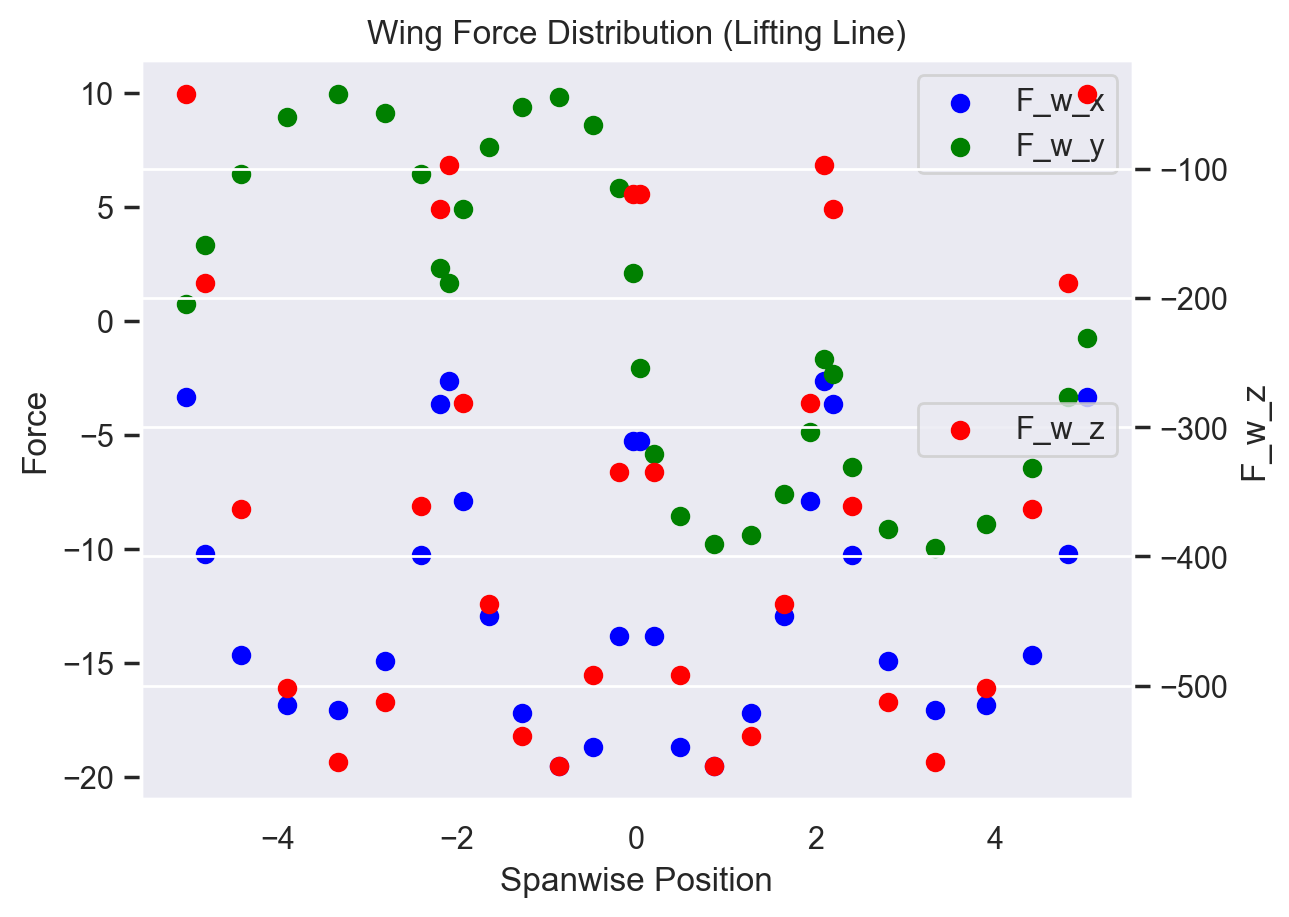

In [11]:
import matplotlib.pyplot as plt
import aerosandbox.numpy as np
# Plot wing forces from lifting line
y = aero_LLT['wing_aero_components']['Wing'].panel_centers[:, 1]  # Spanwise position
F_w = np.array(aero_LLT['wing_aero_components']['Wing'].panel_forces_w)
fig, ax = plt.subplots()

ax.scatter(y, F_w[:, 0], label='F_w_x',color='blue')
second_ax = ax.twinx()
ax.scatter(y, F_w[:, 1], label='F_w_y',color='green')
second_ax.scatter(y, F_w[:, 2], label='F_w_z',color='red')
second_ax.set_ylabel('F_w_z')
ax.set_xlabel('Spanwise Position')
ax.set_ylabel('Force')
ax.set_title('Wing Force Distribution (Lifting Line)')
ax.legend()
ax.grid()
second_ax.legend()

In [12]:
wing = aero_LLT["wing_aero_components"]["Wing"]
y = wing.panel_centers[:, 1]
print(y.min(), y.max(), len(y))
print(np.unique(np.round(y, 6)).shape[0])

0.10187033520040306 4.939321918056585 10
10
